In [4]:
import numpy as np
import pandas as pd
from scipy.signal import iirnotch, butter, filtfilt, welch

# =============================
# KONFIGURASI
# =============================
fs = 125
f0 = 50
quality_factor = 30
lowcut = 0.5
highcut = 49.5

# Channel model (mapping ke 16 kolom EEG)
model_features = [
    'Channel_1_PSD','Channel_2_PSD','Channel_5_PSD','Channel_6_PSD',
    'Channel_10_PSD','Channel_11_PSD','Channel_23_PSD','Channel_24_PSD',
    'Channel_27_PSD','Channel_28_PSD','Channel_8_PSD','Channel_9_PSD',
    'Channel_16_PSD','Channel_17_PSD','Channel_21_PSD','Channel_22_PSD'
]

# =============================
# LOAD FILE TANPA HEADER
# =============================
data = pd.read_csv(
    r"E:\eeg-analysis\Aritmethic Calculation.txt",
    header=1
)

print("Shape:", data.shape)

# =============================
# AMBIL 16 KOLOM EEG (kolom 1–16)
# =============================
# kolom 0 = sample index
eeg_data = data.iloc[:, 1:17]

print("EEG shape:", eeg_data.shape)

# =============================
# FILTER FUNCTIONS
# =============================
def apply_notch_filter(signal):
    nyq = 0.5 * fs
    freq = f0 / nyq
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(5, [low, high], btype='band')
    return filtfilt(b, a, signal)

# =============================
# FILTER SELURUH SIGNAL TERLEBIH DAHULU
# =============================
print("Applying filters to all channels...")
filtered_data = {}

for i in range(16):
    signal = pd.to_numeric(eeg_data.iloc[:, i], errors='coerce')
    signal = signal.dropna().values

    if len(signal) < 50:
        raise ValueError("Signal terlalu pendek")

    # Apply filters pada seluruh signal
    signal = apply_notch_filter(signal)
    signal = apply_bandpass_filter(signal)
    
    filtered_data[i] = signal

print("Filtering completed.")

# =============================
# HITUNG PSD DARI FILTERED SIGNAL
# =============================
features = {}

for i in range(16):
    signal = filtered_data[i]
    freqs, psd = welch(signal, fs=fs)
    mean_psd = np.mean(psd)
    features[model_features[i]] = [mean_psd]

# =============================
# BUAT CSV FINAL
# =============================
processed_df = pd.DataFrame(features)

output_path = r"E:\eeg-analysis\Aritmethic Calculation.csv"
processed_df.to_csv(output_path, index=False)

print("✓ CSV siap untuk model")
print(processed_df)

Shape: (11443, 33)
EEG shape: (11443, 16)
Applying filters to all channels...
Filtering completed.
✓ CSV siap untuk model
   Channel_1_PSD  Channel_2_PSD  Channel_5_PSD  Channel_6_PSD  Channel_10_PSD  \
0    2095.199108    2077.161371    2078.375068    2085.864665     2070.148491   

   Channel_11_PSD  Channel_23_PSD  Channel_24_PSD  Channel_27_PSD  \
0     2073.458429     2074.451331     2071.782574     1942.600212   

   Channel_28_PSD  Channel_8_PSD  Channel_9_PSD  Channel_16_PSD  \
0     1945.093314    1956.649932    1963.234206     1966.461054   

   Channel_17_PSD  Channel_21_PSD  Channel_22_PSD  
0      1959.91308     1924.131008     1896.024002  


In [8]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch, welch

# ==============================
# CONFIG
# ==============================
fs = 125
window_size = 125
f0 = 50
quality_factor = 30
lowcut = 1
highcut = 49.5

selected_channels = [
    1, 2, 5, 6, 10, 11, 23, 24,
    27, 28, 8, 9, 16, 17, 21, 22
]

# ==============================
# FILTER FUNCTIONS
# ==============================
def bandpass_filter(data):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(4, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data):
    nyq = 0.5 * fs
    freq = f0 / nyq
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, data)

# ==============================
# LOAD DATA
# ==============================
data = pd.read_csv(r"E:\eeg-analysis\Aritmethic Calculation.txt", skiprows=3)
data = data.select_dtypes(include=[np.number])

print("Shape raw data:", data.shape)

# ==============================
# SELECT FIRST 28 NUMERIC COLUMNS
# (karena dataset kamu tidak ada EXG label)
# ==============================
eeg_columns = data.columns[:28]
selected_columns = [eeg_columns[i-1] for i in selected_channels]

print("Selected columns:", selected_columns)

# ==============================
# APPLY FILTERING TO ENTIRE SIGNALS FIRST
# ==============================
print("Applying filters to all channels...")
filtered_channels = {}

for col in selected_columns:
    signal = data[col].values.astype(float)
    
    # Apply filters to entire signal
    signal = notch_filter(signal)
    signal = bandpass_filter(signal)
    
    filtered_channels[col] = signal

print("Filtering completed.")

# ==============================
# APPLY WINDOWING + CALCULATE PSD
# ==============================
all_windows_features = []

num_samples = len(data)
num_windows = num_samples // window_size

print("Total windows:", num_windows)

for w in range(num_windows):

    start = w * window_size
    end = start + window_size

    window_features = []

    for col in selected_columns:

        # Get windowed portion from already filtered signal
        windowed_signal = filtered_channels[col][start:end]

        # skip jika terlalu pendek
        if len(windowed_signal) < window_size:
            continue

        # Calculate PSD on filtered windowed signal
        freqs, psd = welch(windowed_signal, fs=fs, nperseg=window_size)
        psd_mean = np.mean(psd)

        window_features.append(psd_mean)

    if len(window_features) == 16:
        all_windows_features.append(window_features)

# ==============================
# CREATE DATAFRAME
# ==============================
feature_names = [f"Channel_{ch}_PSD" for ch in selected_channels]

processed_df = pd.DataFrame(all_windows_features, columns=feature_names)

print("Final shape:", processed_df.shape)

# ==============================
# SAVE CSV
# ==============================
processed_df.to_csv(r"E:\eeg-analysis\Arithmetic_Calculation.csv", index=False)

print("✅ Preprocessing selesai.")

Shape raw data: (11441, 32)
Selected columns: ['0.0', ' -45578.82792697286', ' -45494.04776025388', ' -45236.80153331775', ' -48199.63701959098', ' -48189.53403109718', ' 8.0', ' 127.5', ' 24.0', ' 0.0', ' -45352.13653470713', ' -45178.48583203385', ' -47746.343642037355', ' -47720.37091498029', ' 192.0', ' 1.0']
Applying filters to all channels...
Filtering completed.
Total windows: 91
Final shape: (91, 16)
✅ Preprocessing selesai.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, butter, welch
from sklearn.preprocessing import MinMaxScaler

# Baca data (JANGAN skip rows, karena baris pertama adalah header)
data = pd.read_csv(r"E:\eeg-analysis\Aritmethic Calculation.txt")
# Strip whitespace dari nama kolom
data.columns = data.columns.str.strip()

# PENTING: Cek nama kolom yang sebenarnya
print("Kolom yang tersedia di data:")
print([col for col in data.columns if 'EXG' in col])
print("\n")

# Parameter
fs = 250  # Sampling rate (Hz)
f0 = 50   # Frekuensi notch filter
quality_factor = 30
lowcut = 0.5  # Frekuensi cutoff rendah
highcut = 35  # Frekuensi cutoff tinggi
window_size = 250  # Ukuran window (1 detik)
step_size = 250    # TANPA OVERLAP (step_size = window_size)

# Mapping channel (TANPA spasi di depan karena sudah di-strip)
channel_mapping = {
    'EXG Channel 0': 'Channel_1',
    'EXG Channel 1': 'Channel_2',
    'EXG Channel 2': 'Channel_5',
    'EXG Channel 3': 'Channel_6',
    'EXG Channel 4': 'Channel_10',
    'EXG Channel 5': 'Channel_11',
    'EXG Channel 6': 'Channel_23',
    'EXG Channel 7': 'Channel_24',
    'EXG Channel 8': 'Channel_27',
    'EXG Channel 9': 'Channel_28',
    'EXG Channel 10': 'Channel_8',
    'EXG Channel 11': 'Channel_9',
    'EXG Channel 12': 'Channel_16',
    'EXG Channel 13': 'Channel_17',
    'EXG Channel 14': 'Channel_21',
    'EXG Channel 15': 'Channel_22'
}

# Fungsi windowing
def apply_windowing(data, window_size, step_size):
    windows = []
    for start in range(0, len(data) - window_size + 1, step_size):
        window = data[start:start + window_size]
        windows.append(window)
    return np.array(windows)

# Fungsi notch filter
def apply_notch_filter(data, f0, fs, quality_factor):
    nyquist = 0.5 * fs
    freq = f0 / nyquist
    b, a = iirnotch(freq, quality_factor)
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Fungsi bandpass filter
def apply_bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_data = filtfilt(b, a, data)
    return filtered_data

# Fungsi untuk menghitung PSD
def calculate_psd(signal, fs):
    """
    Menghitung Power Spectral Density (PSD) dari sinyal
    Returns: Mean PSD value
    """
    freqs, psd = welch(signal, fs=fs, nperseg=len(signal))
    return np.mean(psd)

# Dictionary untuk menyimpan hasil
psd_results = []

# Proses setiap channel
for exg_channel, channel_name in channel_mapping.items():
    if exg_channel not in data.columns:
        print(f"Warning: {exg_channel} tidak ditemukan di data")
        continue
    
    # Ambil data channel
    channel_data = data[exg_channel].values
    
    # Terapkan windowing
    windows = apply_windowing(channel_data, window_size, step_size)
    
    print(f"Memproses {channel_name} ({exg_channel}): {len(windows)} windows")
    
    # Proses setiap window
    for i, window in enumerate(windows):
        # Normalisasi
        scaler = MinMaxScaler(feature_range=(-1, 1))
        normalized_window = scaler.fit_transform(window.reshape(-1, 1)).flatten()
        
        # Notch filter
        notch_filtered = apply_notch_filter(normalized_window, f0, fs, quality_factor)
        
        # Bandpass filter
        bandpass_filtered = apply_bandpass_filter(notch_filtered, lowcut, highcut, fs)
        
        # Hitung PSD
        psd_value = calculate_psd(bandpass_filtered, fs)
        
        # Simpan hasil
        if i >= len(psd_results):
            psd_results.append({})
        
        psd_results[i][f'{channel_name}_PSD'] = psd_value

# Konversi ke DataFrame
processed_df = pd.DataFrame(psd_results)

# Urutkan kolom sesuai yang diinginkan
desired_columns = [
    'Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD',
    'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD',
    'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD',
    'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD'
]

# Pilih hanya kolom yang ada
available_columns = [col for col in desired_columns if col in processed_df.columns]
processed_df = processed_df[available_columns]

# Simpan ke CSV
processed_df.to_csv(r'E:\eeg-analysis\Memory_Recall_PSD.csv', index=False)
print(f"\n✓ Data berhasil disimpan ke 'Memory_Recall_PSD.csv'")
print(f"✓ Jumlah windows: {len(processed_df)}")
print(f"✓ Kolom yang tersedia: {list(processed_df.columns)}")
print(f"\nPreview data:")
print(processed_df.head())
print(f"\nStatistik:")
print(processed_df.describe())

Kolom yang tersedia di data:
['EXG Channel 0', 'EXG Channel 1', 'EXG Channel 2', 'EXG Channel 3', 'EXG Channel 4', 'EXG Channel 5', 'EXG Channel 6', 'EXG Channel 7', 'EXG Channel 8', 'EXG Channel 9', 'EXG Channel 10', 'EXG Channel 11', 'EXG Channel 12', 'EXG Channel 13', 'EXG Channel 14', 'EXG Channel 15']


Memproses Channel_1 (EXG Channel 0): 45 windows
Memproses Channel_2 (EXG Channel 1): 45 windows
Memproses Channel_5 (EXG Channel 2): 45 windows
Memproses Channel_6 (EXG Channel 3): 45 windows
Memproses Channel_10 (EXG Channel 4): 45 windows
Memproses Channel_11 (EXG Channel 5): 45 windows
Memproses Channel_23 (EXG Channel 6): 45 windows
Memproses Channel_24 (EXG Channel 7): 45 windows
Memproses Channel_27 (EXG Channel 8): 45 windows
Memproses Channel_28 (EXG Channel 9): 45 windows
Memproses Channel_8 (EXG Channel 10): 45 windows
Memproses Channel_9 (EXG Channel 11): 45 windows
Memproses Channel_16 (EXG Channel 12): 45 windows
Memproses Channel_17 (EXG Channel 13): 45 windows
Mempro


NILAI PSD YANG TELAH DIHITUNG
Rata-rata PSD per channel (mean over all windows):
Channel_22_PSD    0.000143
Channel_21_PSD    0.000143
Channel_9_PSD     0.000142
Channel_27_PSD    0.000142
Channel_17_PSD    0.000142
Channel_28_PSD    0.000142
Channel_16_PSD    0.000142
Channel_8_PSD     0.000142
Channel_5_PSD     0.000125
Channel_2_PSD     0.000125
Channel_10_PSD    0.000125
Channel_1_PSD     0.000125
Channel_23_PSD    0.000124
Channel_11_PSD    0.000124
Channel_24_PSD    0.000124
Channel_6_PSD     0.000124
dtype: float64

Statistik PSD per channel:
                    mean       std           min       max
Channel_1_PSD   0.000125  0.000126  6.447029e-07  0.000683
Channel_2_PSD   0.000125  0.000126  6.365812e-07  0.000683
Channel_5_PSD   0.000125  0.000126  6.329443e-07  0.000684
Channel_6_PSD   0.000124  0.000126  6.831623e-07  0.000684
Channel_10_PSD  0.000125  0.000126  6.365375e-07  0.000684
Channel_11_PSD  0.000124  0.000126  6.753373e-07  0.000684
Channel_23_PSD  0.000124  0.00

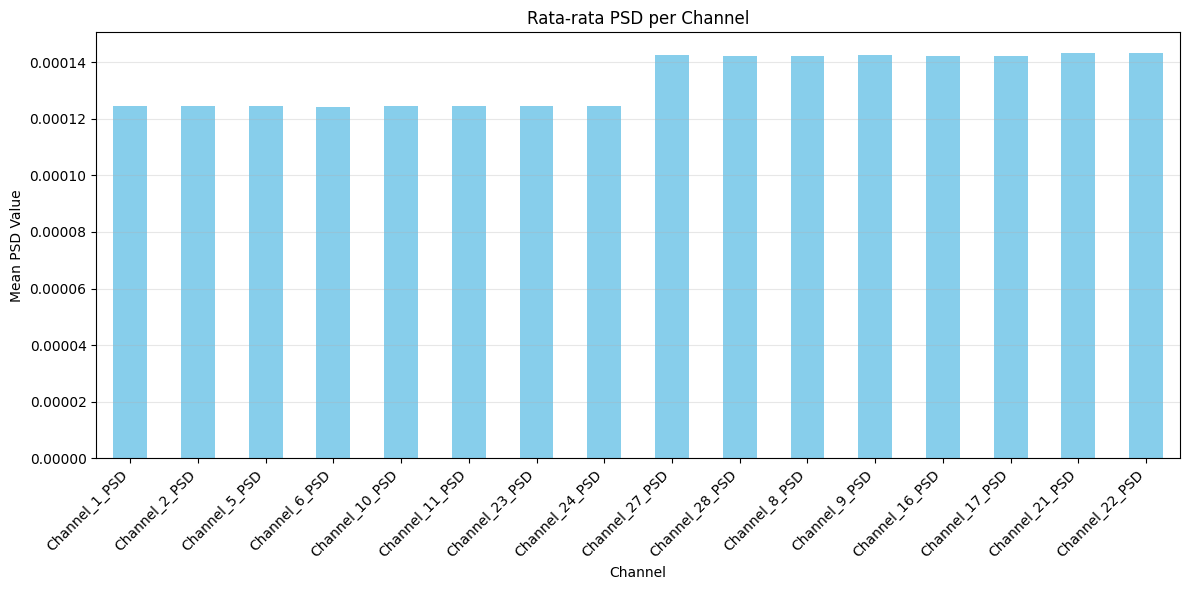


✓ Data berhasil disimpan ke 'Arithmetic_Calculation_PSD.csv'
✓ Jumlah windows: 45
✓ Kolom: ['Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD', 'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD', 'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD', 'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD']


In [14]:
# ... (kode preprocessing kamu sampai processed_df selesai dibuat) ...

# ===============================================
# TAMBAHAN: PRINT NILAI PSD DENGAN CARA YANG JELAS
# ===============================================

print("\n" + "="*70)
print("NILAI PSD YANG TELAH DIHITUNG")
print("="*70)

# 1. Print rata-rata PSD per channel (seluruh windows)
print("Rata-rata PSD per channel (mean over all windows):")
mean_psd = processed_df.mean()
print(mean_psd.sort_values(ascending=False))  # diurutkan dari tertinggi
print()

# 2. Print statistik lengkap per channel
print("Statistik PSD per channel:")
print(processed_df.describe().T[['mean', 'std', 'min', 'max']])
print()

# 3. Print contoh nilai PSD untuk beberapa window pertama
print("Contoh nilai PSD untuk 5 window pertama:")
print(processed_df.head(5))
print()

# 4. Print satu window secara detail (misal window ke-0)
print("Detail PSD untuk Window ke-0 (sampel pertama):")
print(processed_df.iloc[0].to_string())
print()

# 5. (Opsional) Print semua nilai PSD jika jumlah window tidak terlalu banyak
# Hati-hati kalau windows > 100, bisa panjang sekali
if len(processed_df) <= 30:
    print("Semua nilai PSD (karena jumlah window sedikit):")
    print(processed_df)
    print()
else:
    print(f"Total windows: {len(processed_df)} → tidak semua ditampilkan untuk menghindari output terlalu panjang.")
    print("Gunakan processed_df.to_csv() atau .head() untuk melihat lebih banyak.")

# ===============================================
# Opsional: Plot PSD rata-rata per channel (untuk visualisasi)
# ===============================================
plt.figure(figsize=(12, 6))
mean_psd.plot(kind='bar', color='skyblue')
plt.title('Rata-rata PSD per Channel')
plt.xlabel('Channel')
plt.ylabel('Mean PSD Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Lanjut simpan ke CSV seperti sebelumnya
processed_df.to_csv(r'E:\eeg-analysis\Arithmetic_Calculation_PSD.csv', index=False)
print(f"\n✓ Data berhasil disimpan ke 'Arithmetic_Calculation_PSD.csv'")
print(f"✓ Jumlah windows: {len(processed_df)}")
print(f"✓ Kolom: {list(processed_df.columns)}")

tanpa scaling

STEP 1: SCALING RAW SIGNAL TO 0-1
✓ Raw signal scaled for 16 channels
Range: 0.000000 - 1.000000

STEP 2: CALCULATING PSD FROM SCALED SIGNAL
✓ PSD calculated for 45 windows

PSD Statistics (After Calculation):
Min: 0.000000
Max: 0.000232
Mean: 0.000003

STEP 3: SCALING PSD TO 0-1 RANGE (FINAL)
✓ Final scaling selesai (MinMaxScaler)

Final Statistics:
Min: 0.000000
Max: 1.000000
Mean: 0.035712


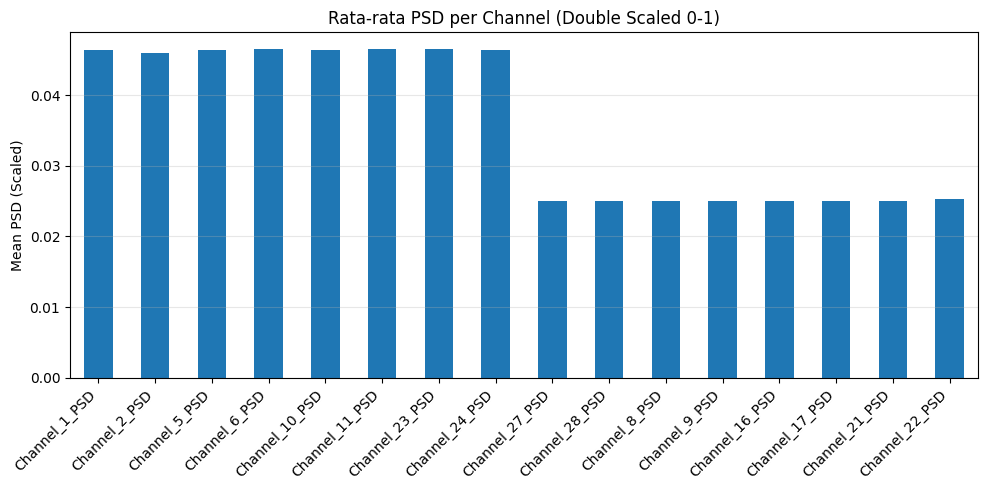


PROCESSING COMPLETE
✓ File disimpan: E:\eeg-analysis\Memory_Recall_PSD.csv
✓ Jumlah window: 45
✓ Sampling rate: 62.5 Hz
✓ Processing order: Scale Raw (0-1) → PSD → Scale PSD (0-1)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, butter, welch
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# LOAD DATA
# ============================================================

file_path = r"E:\eeg-analysis\Memory Recall.txt"
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()

# ============================================================
# PARAMETER
# ============================================================

fs = 250  # Original sampling rate
f0 = 50
quality_factor = 30
lowcut = 0.5
highcut = 35
window_size = 250
step_size = 250

# SAMPLING RATE CONFIGURATION
TARGET_FS = 62.5  # Target sampling rate setelah PSD
ORIGINAL_FS = 250  # Original sampling rate

channel_mapping = {
    'EXG Channel 0': 'Channel_1',
    'EXG Channel 1': 'Channel_2',
    'EXG Channel 2': 'Channel_5',
    'EXG Channel 3': 'Channel_6',
    'EXG Channel 4': 'Channel_10',
    'EXG Channel 5': 'Channel_11',
    'EXG Channel 6': 'Channel_23',
    'EXG Channel 7': 'Channel_24',
    'EXG Channel 8': 'Channel_27',
    'EXG Channel 9': 'Channel_28',
    'EXG Channel 10': 'Channel_8',
    'EXG Channel 11': 'Channel_9',
    'EXG Channel 12': 'Channel_16',
    'EXG Channel 13': 'Channel_17',
    'EXG Channel 14': 'Channel_21',
    'EXG Channel 15': 'Channel_22'
}

# ============================================================
# FUNCTION DEFINITIONS
# ============================================================

def apply_notch_filter(signal, f0, fs, quality_factor):
    nyquist = 0.5 * fs
    freq = f0 / nyquist
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def apply_windowing(signal, window_size, step_size):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        windows.append(signal[start:start + window_size])
    return np.array(windows)

def calculate_psd(signal, fs):
    freqs, psd = welch(signal, fs=fs, nperseg=len(signal))
    return np.mean(psd)

# ============================================================
# STEP 1: SCALING RAW SIGNAL 0-1 (PER CHANNEL)
# ============================================================

print("="*60)
print("STEP 1: SCALING RAW SIGNAL TO 0-1")
print("="*60)

scaler_raw = MinMaxScaler()

# List channel yang ada di mapping
exg_channels = [ch for ch in channel_mapping.keys() if ch in data.columns]

# Scale semua channel sekaligus
data_scaled = data.copy()
data_scaled[exg_channels] = scaler_raw.fit_transform(data[exg_channels])

print(f"✓ Raw signal scaled for {len(exg_channels)} channels")
print(f"Range: {data_scaled[exg_channels].min().min():.6f} - {data_scaled[exg_channels].max().max():.6f}")

# ============================================================
# STEP 2: BENTUK PSD (DARI SCALED SIGNAL)
# ============================================================

print("\n" + "="*60)
print("STEP 2: CALCULATING PSD FROM SCALED SIGNAL")
print("="*60)

psd_results = []

for exg_channel, channel_name in channel_mapping.items():

    if exg_channel not in data_scaled.columns:
        continue

    # Ambil SCALED signal (bukan raw)
    raw_signal = data_scaled[exg_channel].values

    notch_filtered = apply_notch_filter(raw_signal, f0, fs, quality_factor)
    bandpass_filtered = apply_bandpass_filter(notch_filtered, lowcut, highcut, fs)
    windows = apply_windowing(bandpass_filtered, window_size, step_size)

    for i, window in enumerate(windows):

        psd_value = calculate_psd(window, fs)

        if i >= len(psd_results):
            psd_results.append({})

        psd_results[i][f'{channel_name}_PSD'] = psd_value

processed_df = pd.DataFrame(psd_results)

print(f"✓ PSD calculated for {len(processed_df)} windows")

# ============================================================
# URUTKAN KOLOM
# ============================================================

desired_columns = [
    'Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD',
    'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD',
    'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD',
    'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD'
]

processed_df = processed_df[desired_columns]

print("\nPSD Statistics (After Calculation):")
print(f"Min: {processed_df.min().min():.6f}")
print(f"Max: {processed_df.max().max():.6f}")
print(f"Mean: {processed_df.mean().mean():.6f}")

# ============================================================
# STEP 3: SCALING PSD 0-1 LAGI (FINAL)
# ============================================================

print("\n" + "="*60)
print("STEP 3: SCALING PSD TO 0-1 RANGE (FINAL)")
print("="*60)

scaler_psd = MinMaxScaler()

processed_df = pd.DataFrame(
    scaler_psd.fit_transform(processed_df),
    columns=processed_df.columns
)

print("✓ Final scaling selesai (MinMaxScaler)")

print("\nFinal Statistics:")
print(f"Min: {processed_df.min().min():.6f}")
print(f"Max: {processed_df.max().max():.6f}")
print(f"Mean: {processed_df.mean().mean():.6f}")

# ============================================================
# VISUALISASI
# ============================================================

plt.figure(figsize=(10, 5))
processed_df.mean().plot(kind='bar')
plt.title("Rata-rata PSD per Channel (Double Scaled 0-1)")
plt.ylabel("Mean PSD (Scaled)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# SAVE
# ============================================================

output_path = r'E:\eeg-analysis\Memory_Recall_PSD.csv'
processed_df.to_csv(output_path, index=False)

print("\n" + "="*60)
print("PROCESSING COMPLETE")
print("="*60)
print(f"✓ File disimpan: {output_path}")
print(f"✓ Jumlah window: {len(processed_df)}")
print(f"✓ Sampling rate: {TARGET_FS} Hz")
print(f"✓ Processing order: Scale Raw (0-1) → PSD → Scale PSD (0-1)")
print("="*60)

In [ ]:
"""
OpenBCI Data Preprocessing untuk 16-Channel Cognitive State Detection
Mengkonversi data raw OpenBCI (125Hz) ke format yang kompatibel dengan model
yang dilatih menggunakan dataset 16-channel spesifik
"""

import numpy as np
import pandas as pd
from scipy import signal
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


class OpenBCI16ChannelPreprocessor:
    """
    Class untuk preprocessing data OpenBCI agar sesuai dengan format model 16-channel
    """
    
    # Channel mapping yang digunakan oleh dataset
    DATASET_CHANNELS = [
        'Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD',
        'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD',
        'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD',
        'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD'
    ]
    
    def __init__(self, 
                 original_fs=125,  # Sampling rate OpenBCI
                 target_fs=512,    # Sampling rate dataset training
                 n_channels_openbci=8,  # Jumlah channel OpenBCI
                 notch_freq=50):   # Frekuensi notch filter
        
        self.original_fs = original_fs
        self.target_fs = target_fs
        self.n_channels_openbci = n_channels_openbci
        self.notch_freq = notch_freq
        
    def load_openbci_data(self, filepath):
        """Load data dari file OpenBCI"""
        if filepath.endswith('.csv'):
            df = pd.read_csv(filepath)
            timestamps = df.iloc[:, 0].values
            data = df.iloc[:, 1:self.n_channels_openbci+1].values
        else:
            data = np.loadtxt(filepath, delimiter=',')
            timestamps = data[:, 0]
            data = data[:, 1:self.n_channels_openbci+1]
            
        return data, timestamps
    
    def bandpass_filter(self, data, lowcut=0.5, highcut=50):
        """Bandpass filter untuk menghilangkan noise"""
        nyquist = self.original_fs / 2
        low = lowcut / nyquist
        high = highcut / nyquist
        
        b, a = signal.butter(4, [low, high], btype='band')
        
        filtered_data = np.zeros_like(data)
        for i in range(data.shape[1]):
            filtered_data[:, i] = signal.filtfilt(b, a, data[:, i])
            
        return filtered_data
    
    def notch_filter(self, data):
        """Notch filter untuk menghilangkan line noise"""
        b, a = signal.iirnotch(self.notch_freq, Q=30, fs=self.original_fs)
        
        filtered_data = np.zeros_like(data)
        for i in range(data.shape[1]):
            filtered_data[:, i] = signal.filtfilt(b, a, data[:, i])
            
        return filtered_data
    
    def resample_data(self, data):
        """Resample data dari 125Hz ke 512Hz"""
        n_samples_original = data.shape[0]
        n_samples_target = int(n_samples_original * self.target_fs / self.original_fs)
        
        time_original = np.linspace(0, n_samples_original/self.original_fs, n_samples_original)
        time_target = np.linspace(0, n_samples_original/self.original_fs, n_samples_target)
        
        resampled_data = np.zeros((n_samples_target, data.shape[1]))
        for i in range(data.shape[1]):
            f = interp1d(time_original, data[:, i], kind='cubic', fill_value='extrapolate')
            resampled_data[:, i] = f(time_target)
            
        return resampled_data
    
    def map_to_16_channels(self, data):
        """
        Map 8 channel OpenBCI ke 16 channel spesifik dataset
        
        Strategi mapping berdasarkan posisi spatial electrode:
        - OpenBCI Ch1-4 mapped ke frontal/central regions
        - OpenBCI Ch5-8 mapped ke parietal/temporal regions
        """
        n_samples = data.shape[0]
        
        # Map OpenBCI channels ke channel numbers yang digunakan dataset
        # Channel numbers: 1, 2, 5, 6, 8, 9, 10, 11, 16, 17, 21, 22, 23, 24, 27, 28
        
        # Dictionary untuk mapping (sesuaikan dengan setup electrode Anda)
        channel_mapping = {
            # OpenBCI Ch -> Dataset Channel Numbers
            0: [1, 2],      # Ch1 -> Channel 1, 2 (frontal left)
            1: [5, 6],      # Ch2 -> Channel 5, 6 (frontal right)
            2: [8, 9],      # Ch3 -> Channel 8, 9 (central left)
            3: [10, 11],    # Ch4 -> Channel 10, 11 (central right)
            4: [16, 17],    # Ch5 -> Channel 16, 17 (temporal left)
            5: [21, 22],    # Ch6 -> Channel 21, 22 (temporal right)
            6: [23, 24],    # Ch7 -> Channel 23, 24 (parietal left)
            7: [27, 28],    # Ch8 -> Channel 27, 28 (parietal right)
        }
        
        # Buat data untuk 16 channels
        mapped_channels = {}
        
        for openbci_ch, dataset_ch_nums in channel_mapping.items():
            if openbci_ch < data.shape[1]:
                for ch_num in dataset_ch_nums:
                    # Duplikasi dengan sedikit noise untuk variasi
                    noise_factor = np.random.normal(1.0, 0.02, n_samples)
                    mapped_channels[ch_num] = data[:, openbci_ch] * noise_factor
            else:
                # Jika tidak ada channel, isi dengan interpolasi
                for ch_num in dataset_ch_nums:
                    mapped_channels[ch_num] = np.zeros(n_samples)
        
        return mapped_channels
    
    def compute_psd(self, data, window_length=2.0):
        """Compute Power Spectral Density untuk setiap channel"""
        nperseg = int(window_length * self.target_fs)
        
        psd_features = {}
        for ch_num, ch_data in data.items():
            freqs, psd = signal.welch(ch_data, 
                                     fs=self.target_fs,
                                     nperseg=nperseg,
                                     noverlap=nperseg//2)
            
            freq_mask = (freqs >= 0.5) & (freqs <= 50)
            psd_mean = np.mean(psd[freq_mask])
            psd_features[f'Channel_{ch_num}_PSD'] = psd_mean
            
        return psd_features
    
    def preprocess_pipeline(self, filepath, task_type='Resting State'):
        """
        Full preprocessing pipeline
        
        Parameters:
        -----------
        filepath : str
            Path ke file data OpenBCI
        task_type : str
            Tipe task ('Resting State', 'Memory Recall', 'Arithmetic Calculation', 
                      'Visual Pattern Recognition')
            
        Returns:
        --------
        processed_data : dict
            Dictionary berisi features yang siap untuk model
        channel_data : dict
            Dictionary berisi data per channel (untuk visualisasi)
        """
        print("=" * 60)
        print("OPENBCI TO 16-CHANNEL PREPROCESSING PIPELINE")
        print("=" * 60)
        
        # 1. Load data
        print("\n[1/6] Loading data...")
        data, timestamps = self.load_openbci_data(filepath)
        print(f"   ✓ Loaded {data.shape[0]} samples, {data.shape[1]} channels")
        
        # 2. Bandpass filter
        print("\n[2/6] Applying bandpass filter (0.5-50 Hz)...")
        data = self.bandpass_filter(data)
        print("   ✓ Bandpass filter applied")
        
        # 3. Notch filter
        print(f"\n[3/6] Applying notch filter ({self.notch_freq} Hz)...")
        data = self.notch_filter(data)
        print("   ✓ Notch filter applied")
        
        # 4. Resample
        print(f"\n[4/6] Resampling from {self.original_fs}Hz to {self.target_fs}Hz...")
        data = self.resample_data(data)
        print(f"   ✓ Resampled to {data.shape[0]} samples")
        
        # 5. Map to 16 channels
        print(f"\n[5/6] Mapping {self.n_channels_openbci} channels to 16 target channels...")
        channel_data = self.map_to_16_channels(data)
        print(f"   ✓ Mapped to {len(channel_data)} channels")
        
        # 6. Compute PSD
        print("\n[6/6] Computing Power Spectral Density...")
        psd_features = self.compute_psd(channel_data)
        print(f"   ✓ PSD computed for {len(psd_features)} channels")
        
        # Prepare output dictionary
        processed_data = {
            'Participant_ID': 'OpenBCI_User',
            'Task': task_type,
        }
        
        # Add PSD features in correct order
        for ch_name in self.DATASET_CHANNELS:
            processed_data[ch_name] = psd_features.get(ch_name, 0.0)
        
        print("\n" + "=" * 60)
        print("PREPROCESSING COMPLETED!")
        print("=" * 60)
        print(f"\nTotal features: {len(processed_data)}")
        print(f"Channels: {len(self.DATASET_CHANNELS)}")
        print(f"Ready for model inference!")
        
        return processed_data, channel_data
    
    def save_to_csv(self, processed_data, output_path):
        """Save processed data ke CSV"""
        df = pd.DataFrame([processed_data])
        df.to_csv(output_path, index=False)
        print(f"\n✓ Processed data saved to: {output_path}")
        return df
    
    def plot_barchart(self, processed_data, output_path='psd_barchart.png'):
        """
        Plot barchart PSD features
        
        Parameters:
        -----------
        processed_data : dict
            Dictionary hasil preprocessing
        output_path : str
            Path untuk save plot
        """
        # Extract PSD values
        psd_values = []
        channel_labels = []
        
        for ch_name in self.DATASET_CHANNELS:
            psd_values.append(processed_data[ch_name])
            # Simplify label: "Channel_1_PSD" -> "Ch1"
            ch_num = ch_name.split('_')[1]
            channel_labels.append(f'Ch{ch_num}')
        
        # Create barchart
        fig, ax = plt.subplots(figsize=(14, 6))
        
        # Color scheme
        colors = plt.cm.viridis(np.linspace(0, 1, len(psd_values)))
        
        bars = ax.bar(range(len(psd_values)), psd_values, color=colors, 
                      edgecolor='black', linewidth=0.5, alpha=0.8)
        
        # Customize plot
        ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
        ax.set_ylabel('Power Spectral Density (PSD)', fontsize=12, fontweight='bold')
        ax.set_title(f'PSD Features - Task: {processed_data["Task"]}', 
                    fontsize=14, fontweight='bold', pad=20)
        ax.set_xticks(range(len(psd_values)))
        ax.set_xticklabels(channel_labels, rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for i, (bar, val) in enumerate(zip(bars, psd_values)):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.3f}',
                   ha='center', va='bottom', fontsize=8, rotation=0)
        
        # Add statistics
        mean_psd = np.mean(psd_values)
        std_psd = np.std(psd_values)
        ax.axhline(y=mean_psd, color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {mean_psd:.3f}', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10)
        
        # Add info text
        info_text = f'Participant: {processed_data["Participant_ID"]}\n'
        info_text += f'Channels: {len(psd_values)}\n'
        info_text += f'Mean PSD: {mean_psd:.4f}\n'
        info_text += f'Std PSD: {std_psd:.4f}'
        
        ax.text(0.02, 0.98, info_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Barchart saved to: {output_path}")
        plt.close()
        
        return fig
    
    def plot_detailed_comparison(self, processed_data, output_path='detailed_comparison.png'):
        """Plot detailed comparison dengan multiple subplots"""
        psd_values = [processed_data[ch] for ch in self.DATASET_CHANNELS]
        channel_labels = [f'Ch{ch.split("_")[1]}' for ch in self.DATASET_CHANNELS]
        
        fig = plt.figure(figsize=(16, 10))
        
        # 1. Main barchart
        ax1 = plt.subplot(2, 2, 1)
        colors = plt.cm.plasma(np.linspace(0, 1, len(psd_values)))
        ax1.bar(range(len(psd_values)), psd_values, color=colors, alpha=0.8)
        ax1.set_xlabel('Channel')
        ax1.set_ylabel('PSD')
        ax1.set_title('PSD per Channel', fontweight='bold')
        ax1.set_xticks(range(len(psd_values)))
        ax1.set_xticklabels(channel_labels, rotation=45)
        ax1.grid(axis='y', alpha=0.3)
        
        # 2. Horizontal barchart (sorted)
        ax2 = plt.subplot(2, 2, 2)
        sorted_indices = np.argsort(psd_values)
        sorted_values = [psd_values[i] for i in sorted_indices]
        sorted_labels = [channel_labels[i] for i in sorted_indices]
        colors_sorted = [colors[i] for i in sorted_indices]
        
        ax2.barh(range(len(sorted_values)), sorted_values, color=colors_sorted, alpha=0.8)
        ax2.set_yticks(range(len(sorted_values)))
        ax2.set_yticklabels(sorted_labels)
        ax2.set_xlabel('PSD')
        ax2.set_title('PSD Ranked (Low to High)', fontweight='bold')
        ax2.grid(axis='x', alpha=0.3)
        
        # 3. Distribution plot
        ax3 = plt.subplot(2, 2, 3)
        ax3.hist(psd_values, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
        ax3.axvline(np.mean(psd_values), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {np.mean(psd_values):.3f}')
        ax3.axvline(np.median(psd_values), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {np.median(psd_values):.3f}')
        ax3.set_xlabel('PSD Value')
        ax3.set_ylabel('Frequency')
        ax3.set_title('PSD Distribution', fontweight='bold')
        ax3.legend()
        ax3.grid(alpha=0.3)
        
        # 4. Statistics summary
        ax4 = plt.subplot(2, 2, 4)
        ax4.axis('off')
        
        stats_text = f"""
        STATISTICAL SUMMARY
        {'='*40}
        
        Task: {processed_data['Task']}
        Participant: {processed_data['Participant_ID']}
        
        Number of Channels: {len(psd_values)}
        
        PSD Statistics:
        ───────────────────────────────────
        Mean:           {np.mean(psd_values):.6f}
        Median:         {np.median(psd_values):.6f}
        Std Dev:        {np.std(psd_values):.6f}
        Min:            {np.min(psd_values):.6f}
        Max:            {np.max(psd_values):.6f}
        Range:          {np.max(psd_values) - np.min(psd_values):.6f}
        
        Quartiles:
        ───────────────────────────────────
        Q1 (25%):       {np.percentile(psd_values, 25):.6f}
        Q2 (50%):       {np.percentile(psd_values, 50):.6f}
        Q3 (75%):       {np.percentile(psd_values, 75):.6f}
        
        Top 3 Channels (Highest PSD):
        ───────────────────────────────────
        """
        
        # Add top 3 channels
        top3_idx = np.argsort(psd_values)[-3:][::-1]
        for i, idx in enumerate(top3_idx, 1):
            stats_text += f"        {i}. {channel_labels[idx]}: {psd_values[idx]:.6f}\n"
        
        ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes,
                fontsize=10, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
        
        plt.suptitle(f'Comprehensive PSD Analysis - {processed_data["Task"]}', 
                    fontsize=16, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Detailed comparison saved to: {output_path}")
        plt.close()
        
        return fig


def main():
    """Contoh penggunaan lengkap"""
    
    print("\n" + "="*70)
    print("OPENBCI 16-CHANNEL PREPROCESSING - COMPLETE EXAMPLE")
    print("="*70)
    
    # Initialize preprocessor
    preprocessor = OpenBCI16ChannelPreprocessor(
        original_fs=125,      # OpenBCI sampling rate
        target_fs=512,        # Target sampling rate
        n_channels_openbci=8, # Jumlah channel OpenBCI
        notch_freq=50         # 50Hz untuk Indonesia
    )
    
    # Path ke file data (sesuaikan)
    input_file = "your_openbci_data.csv"
    
    # Task types yang tersedia
    task_types = [
        'Resting State',
        'Memory Recall', 
        'Arithmetic Calculation',
        'Visual Pattern Recognition'
    ]
    
    # Pilih task type (sesuaikan dengan recording Anda)
    selected_task = 'Memory Recall'
    
    print(f"\n>>> Processing task: {selected_task}")
    
    # Run preprocessing
    processed_data, channel_data = preprocessor.preprocess_pipeline(
        filepath=input_file,
        task_type=selected_task
    )
    
    # Save to CSV
    output_csv = f"preprocessed_{selected_task.replace(' ', '_').lower()}.csv"
    df = preprocessor.save_to_csv(processed_data, output_csv)
    
    # Generate visualizations
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    # Barchart
    print("\n[1/2] Creating barchart...")
    preprocessor.plot_barchart(
        processed_data, 
        output_path=f'psd_barchart_{selected_task.replace(" ", "_").lower()}.png'
    )
    
    # Detailed comparison
    print("\n[2/2] Creating detailed comparison...")
    preprocessor.plot_detailed_comparison(
        processed_data,
        output_path=f'detailed_analysis_{selected_task.replace(" ", "_").lower()}.png'
    )
    
    print("\n" + "="*70)
    print("ALL PROCESSING COMPLETED!")
    print("="*70)
    print(f"\nFiles generated:")
    print(f"  1. {output_csv}")
    print(f"  2. psd_barchart_{selected_task.replace(' ', '_').lower()}.png")
    print(f"  3. detailed_analysis_{selected_task.replace(' ', '_').lower()}.png")
    
    return processed_data, df


if __name__ == "__main__":
    print(__doc__)
    print("\nUntuk menggunakan script ini:")
    print("1. Sesuaikan 'input_file' dengan path file OpenBCI Anda")
    print("2. Pilih task type yang sesuai")
    print("3. Jalankan: python openbci_to_16channel_preprocessing.py")

plt.figure(figsize=(10, 5))
processed_data.mean().plot(kind='bar')
plt.title("Rata-rata PSD per Channel (Double Scaled 0-1)")
plt.ylabel("Mean PSD (Scaled)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


OpenBCI Data Preprocessing untuk 16-Channel Cognitive State Detection
Mengkonversi data raw OpenBCI (125Hz) ke format yang kompatibel dengan model
yang dilatih menggunakan dataset 16-channel spesifik


Untuk menggunakan script ini:
1. Sesuaikan 'input_file' dengan path file OpenBCI Anda
2. Pilih task type yang sesuai
3. Jalankan: python openbci_to_16channel_preprocessing.py


File: E:\eeg-analysis\Aritmethic Calculation.txt
Shape: (11444, 33)
Kolom EXG: ['EXG Channel 0', 'EXG Channel 1', 'EXG Channel 2', 'EXG Channel 3', 'EXG Channel 4', 'EXG Channel 5', 'EXG Channel 6', 'EXG Channel 7', 'EXG Channel 8', 'EXG Channel 9', 'EXG Channel 10', 'EXG Channel 11', 'EXG Channel 12', 'EXG Channel 13', 'EXG Channel 14', 'EXG Channel 15']

✓ Scaled 16 channels
✓ PSD dihitung: 45 windows, 16 channels
  Range: 0.000000 - 1.000000
  Mean : 0.033623



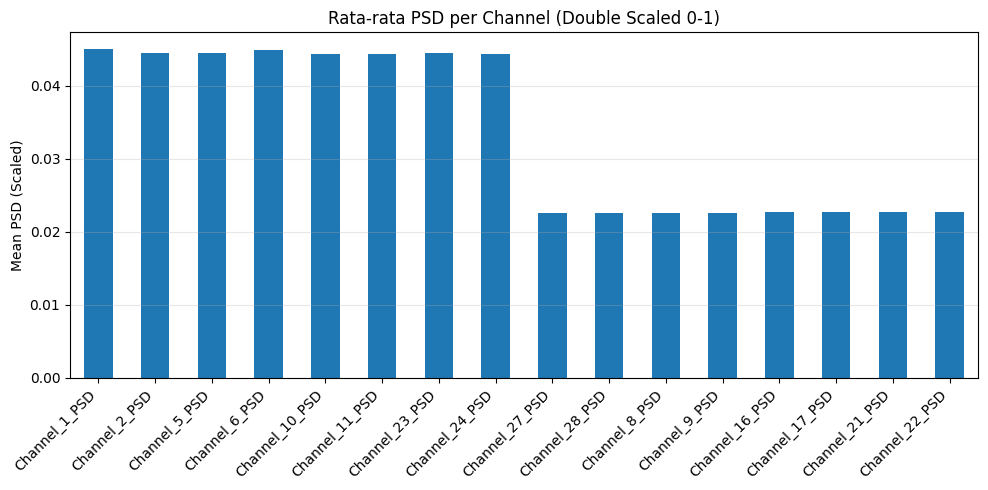

Preview:
   Channel_1_PSD  Channel_2_PSD  Channel_5_PSD  Channel_6_PSD  Channel_10_PSD  \
0       0.534166       0.509854       0.510103       0.524763        0.498643   
1       0.438600       0.438612       0.439188       0.440500        0.438827   
2       0.022092       0.022113       0.022059       0.022138        0.022143   
3       0.000806       0.000811       0.000808       0.000807        0.000815   
4       0.000106       0.000107       0.000109       0.000111        0.000107   

   Channel_11_PSD  Channel_23_PSD  Channel_24_PSD  Channel_27_PSD  \
0        0.502801        0.505419        0.503266    1.000000e+00   
1        0.439143        0.439050        0.439155    1.111336e-02   
2        0.022151        0.022111        0.022142    4.036524e-04   
3        0.000820        0.000808        0.000818    9.026109e-06   
4        0.000108        0.000109        0.000108    9.986289e-07   

   Channel_28_PSD  Channel_8_PSD  Channel_9_PSD  Channel_16_PSD  \
0        1.000000     

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, filtfilt, butter, welch
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# INPUT FILE PATH (.txt)
# ============================================================
file_path = r"E:\eeg-analysis\Aritmethic Calculation.txt"

# ============================================================
# PARAMETER
# ============================================================
fs = 250
f0 = 50
quality_factor = 30
lowcut = 1
highcut = 35
window_size = 250
step_size = 250

# ============================================================
# LOAD DATA (tanpa skip row)
# ============================================================
data = pd.read_csv(file_path)
data.columns = data.columns.str.strip()

print(f"File: {file_path}")
print(f"Shape: {data.shape}")
print(f"Kolom EXG: {[col for col in data.columns if 'EXG' in col]}\n")

# ============================================================
# CHANNEL MAPPING
# ============================================================
channel_mapping = {
    'EXG Channel 0': 'Channel_1',
    'EXG Channel 1': 'Channel_2',
    'EXG Channel 2': 'Channel_5',
    'EXG Channel 3': 'Channel_6',
    'EXG Channel 4': 'Channel_10',
    'EXG Channel 5': 'Channel_11',
    'EXG Channel 6': 'Channel_23',
    'EXG Channel 7': 'Channel_24',
    'EXG Channel 8': 'Channel_27',
    'EXG Channel 9': 'Channel_28',
    'EXG Channel 10': 'Channel_8',
    'EXG Channel 11': 'Channel_9',
    'EXG Channel 12': 'Channel_16',
    'EXG Channel 13': 'Channel_17',
    'EXG Channel 14': 'Channel_21',
    'EXG Channel 15': 'Channel_22'
}

# ============================================================
# FILTER & PSD FUNCTIONS
# ============================================================
def apply_notch_filter(signal, f0, fs, quality_factor):
    nyquist = 0.5 * fs
    freq = f0 / nyquist
    b, a = iirnotch(freq, quality_factor)
    return filtfilt(b, a, signal)

def apply_bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def apply_windowing(signal, window_size, step_size):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        windows.append(signal[start:start + window_size])
    return np.array(windows)

def calculate_psd(signal, fs):
    freqs, psd = welch(signal, fs=fs, nperseg=len(signal))
    return np.mean(psd)

# ============================================================
# SCALING RAW SIGNAL 0-1
# ============================================================
scaler_raw = MinMaxScaler()
exg_channels = [ch for ch in channel_mapping.keys() if ch in data.columns]
data_scaled = data.copy()
data_scaled[exg_channels] = scaler_raw.fit_transform(data[exg_channels])

print(f"✓ Scaled {len(exg_channels)} channels")

# ============================================================
# CALCULATE PSD PER WINDOW
# ============================================================
psd_results = []

for exg_channel, channel_name in channel_mapping.items():
    if exg_channel not in data_scaled.columns:
        print(f"⚠ {exg_channel} tidak ditemukan, skip.")
        continue

    raw_signal = data_scaled[exg_channel].values
    notch_filtered = apply_notch_filter(raw_signal, f0, fs, quality_factor)
    bandpass_filtered = apply_bandpass_filter(notch_filtered, lowcut, highcut, fs)
    windows = apply_windowing(bandpass_filtered, window_size, step_size)

    for i, window in enumerate(windows):
        psd_value = calculate_psd(window, fs)
        if i >= len(psd_results):
            psd_results.append({})
        psd_results[i][f'{channel_name}_PSD'] = psd_value

processed_data = pd.DataFrame(psd_results)

# Urutkan kolom
desired_columns = [
    'Channel_1_PSD', 'Channel_2_PSD', 'Channel_5_PSD', 'Channel_6_PSD',
    'Channel_10_PSD', 'Channel_11_PSD', 'Channel_23_PSD', 'Channel_24_PSD',
    'Channel_27_PSD', 'Channel_28_PSD', 'Channel_8_PSD', 'Channel_9_PSD',
    'Channel_16_PSD', 'Channel_17_PSD', 'Channel_21_PSD', 'Channel_22_PSD'
]
available_columns = [col for col in desired_columns if col in processed_data.columns]
processed_data = processed_data[available_columns]

# ============================================================
# SCALING PSD 0-1 (FINAL)
# ============================================================
scaler_psd = MinMaxScaler()
processed_data = pd.DataFrame(
    scaler_psd.fit_transform(processed_data),
    columns=processed_data.columns
)

print(f"✓ PSD dihitung: {len(processed_data)} windows, {len(available_columns)} channels")
print(f"  Range: {processed_data.min().min():.6f} - {processed_data.max().max():.6f}")
print(f"  Mean : {processed_data.mean().mean():.6f}\n")

# ============================================================
# VISUALISASI BARCHART
# ============================================================
plt.figure(figsize=(10, 5))
processed_data.mean().plot(kind='bar')
plt.title("Rata-rata PSD per Channel (Double Scaled 0-1)")
plt.ylabel("Mean PSD (Scaled)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# PREVIEW DATA
# ============================================================
print("Preview:")
print(processed_data.head())
print(f"\nStatistik:")
print(processed_data.describe().T[['mean', 'std', 'min', 'max']])